Calculate the avg marks and prin t class fialed or passed is the avg is 50 or above

In [20]:
marks = [45, 60, 72, 38, 90]

total = 0

for i in range(len(marks) - 1):
    total += marks[i]

average = total / len(marks)

if average > 50:
    print("Class passed")
else:
    print("Class failed")

print("Average:", average)

Class failed
Average: 43.0


In [21]:
import pandas as pd

In [22]:
data = {
    "student_id": [101, 102, 103, 104, 105, 106],
    "attendance_percent": [92, 67, 81, 45, 74, 88],
    "assignment_score": [18, 12, 15, 8, 14, 19],
    "quiz_score": [72, 48, 65, 30, 55, 80],
    "lab_completed": [True, False, True, False, True, True]
}

df = pd.DataFrame(data)

df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed
0,101,92,18,72,True
1,102,67,12,48,False
2,103,81,15,65,True
3,104,45,8,30,False
4,105,74,14,55,True
5,106,88,19,80,True


In [23]:
df.shape

(6, 5)

In [24]:
df.head()

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed
0,101,92,18,72,True
1,102,67,12,48,False
2,103,81,15,65,True
3,104,45,8,30,False
4,105,74,14,55,True


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   student_id          6 non-null      int64
 1   attendance_percent  6 non-null      int64
 2   assignment_score    6 non-null      int64
 3   quiz_score          6 non-null      int64
 4   lab_completed       6 non-null      bool 
dtypes: bool(1), int64(4)
memory usage: 330.0 bytes


In [26]:
df.describe()

,student_id,attendance_percent,assignment_score,quiz_score
count,6.000000,6.000000,6.000000,6.000000
mean,103.500000,74.500000,14.333333,58.333333
std,1.870829,17.073371,4.033196,18.007406
min,101.000000,45.000000,8.000000,30.000000
25%,102.250000,68.750000,12.500000,49.750000
50%,103.500000,77.500000,14.500000,60.000000
75%,104.750000,86.250000,17.250000,70.250000
max,106.000000,92.000000,19.000000,80.000000


In [27]:
df['total_score'] = df['assignment_score'] + df['quiz_score']
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score
0,101,92,18,72,True,90
1,102,67,12,48,False,60
2,103,81,15,65,True,80
3,104,45,8,30,False,38
4,105,74,14,55,True,69
5,106,88,19,80,True,99


In [28]:
df['eligible'] = (
    (df['attendance_percent'] >= 75) &
    (df['total_score'] >= 70) &
    (df['lab_completed'])
)
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible
0,101,92,18,72,True,90,True
1,102,67,12,48,False,60,False
2,103,81,15,65,True,80,True
3,104,45,8,30,False,38,False
4,105,74,14,55,True,69,False
5,106,88,19,80,True,99,True


In [29]:
eligible_students = df[df["eligible"] == True]
eligible_students

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible
0,101,92,18,72,True,90,True
2,103,81,15,65,True,80,True
5,106,88,19,80,True,99,True


## Additional Feature Engineering

Created new features to understand student performance better.

In [30]:
# Feature 1: Average Score
df['average_score'] = df['total_score'] / 2
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible,average_score
0,101,92,18,72,True,90,True,45.0
1,102,67,12,48,False,60,False,30.0
2,103,81,15,65,True,80,True,40.0
3,104,45,8,30,False,38,False,19.0
4,105,74,14,55,True,69,False,34.5
5,106,88,19,80,True,99,True,49.5


In [31]:
# Feature 2: Attendance Category
def attendance_status(x):
    if x >= 85:
        return 'Excellent'
    elif x >= 75:
        return 'Good'
    else:
        return 'Poor'

df['attendance_status'] = df['attendance_percent'].apply(attendance_status)
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible,average_score,attendance_status
0,101,92,18,72,True,90,True,45.0,Excellent
1,102,67,12,48,False,60,False,30.0,Poor
2,103,81,15,65,True,80,True,40.0,Good
3,104,45,8,30,False,38,False,19.0,Poor
4,105,74,14,55,True,69,False,34.5,Poor
5,106,88,19,80,True,99,True,49.5,Excellent


In [32]:
# Feature 3: Performance Category
def performance_category(score):
    if score >= 85:
        return 'Excellent'
    elif score >= 70:
        return 'Good'
    else:
        return 'Needs Improvement'

df['performance_category'] = df['total_score'].apply(performance_category)
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible,average_score,attendance_status,performance_category
0,101,92,18,72,True,90,True,45.0,Excellent,Excellent
1,102,67,12,48,False,60,False,30.0,Poor,Needs Improvement
2,103,81,15,65,True,80,True,40.0,Good,Good
3,104,45,8,30,False,38,False,19.0,Poor,Needs Improvement
4,105,74,14,55,True,69,False,34.5,Poor,Needs Improvement
5,106,88,19,80,True,99,True,49.5,Excellent,Excellent


## Data Visualization using Matplotlib

In [33]:
import matplotlib.pyplot as plt

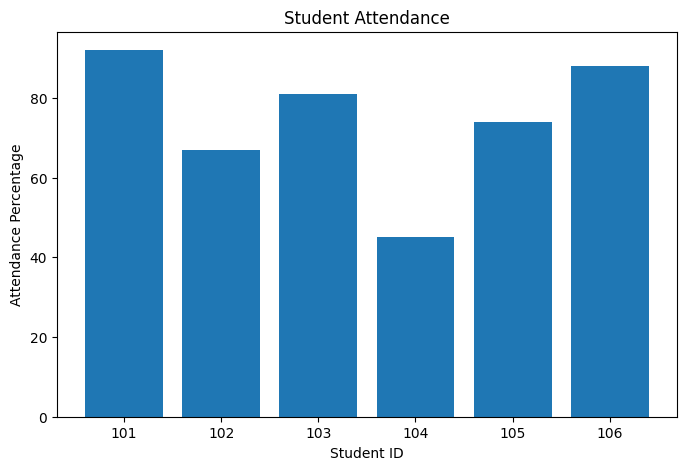

In [34]:
# Graph 1: Student Attendance
plt.figure(figsize=(8,5))
plt.bar(df['student_id'], df['attendance_percent'])
plt.xlabel('Student ID')
plt.ylabel('Attendance Percentage')
plt.title('Student Attendance')
plt.show()

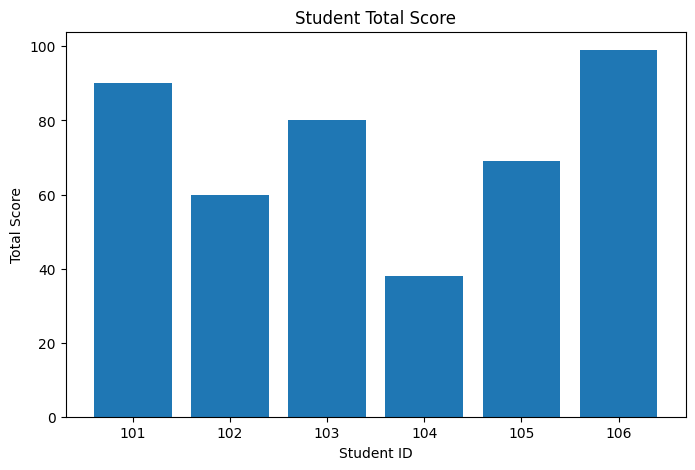

In [35]:
# Graph 2: Student Total Score
plt.figure(figsize=(8,5))
plt.bar(df['student_id'], df['total_score'])
plt.xlabel('Student ID')
plt.ylabel('Total Score')
plt.title('Student Total Score')
plt.show()

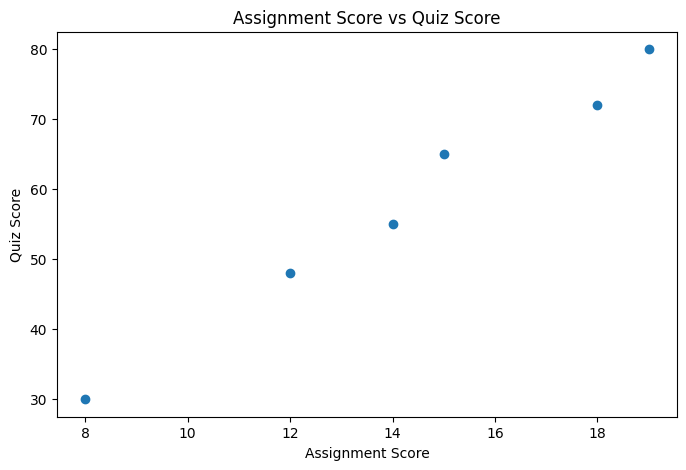

In [36]:
# Graph 3: Assignment Score vs Quiz Score
plt.figure(figsize=(8,5))
plt.scatter(df['assignment_score'], df['quiz_score'])
plt.xlabel('Assignment Score')
plt.ylabel('Quiz Score')
plt.title('Assignment Score vs Quiz Score')
plt.show()

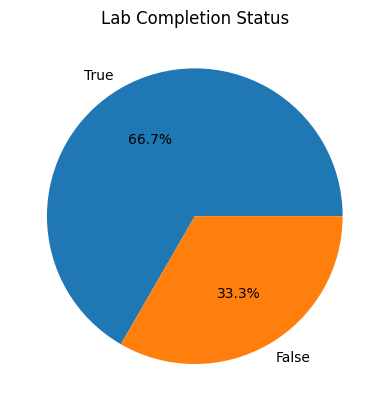

In [37]:
# Graph 4: Lab Completion Status
lab_count = df['lab_completed'].value_counts()
plt.pie(lab_count, labels=lab_count.index, autopct='%1.1f%%')
plt.title('Lab Completion Status')
plt.show()

## Observations

1. Students have different attendance percentages.
2. Total score helps compare overall student performance.
3. Feature engineering creates new information from existing data.
4. Visualizations help understand patterns in student data.